# Psychometric Game-Based Credit Scoring (Model B): Chess Demo

This is the companion to `SocialMediaEngine.ipynb` (Model A). The proposal's Model B builds a credit risk score from gameplay behavior, hypothesizing that how someone plays games (risk tolerance, time management, recovery from failure, discipline) reveals their financial decision-making patterns.

This notebook walks through:

**Phase 1: The dataset hunt.** We evaluate four candidate datasets across League of Legends, generic online gaming behavior, and chess. Three are rejected with documented reasons. The fourth (Lichess Elite Database) becomes our working dataset.

**Phase 2: Parse and aggregate.** We stream-parse hundreds of thousands of chess games from a single month, extracting per-player behavioral features that map to the proposal's psychometric pillars.

**Phase 3: Feature engineering and EDA.** Iterate on features, drop redundant ones, build proposal-aligned signals like opening entropy, color asymmetry, and late-night play share.

**Phase 4: Target construction.** Build a composite credit risk target from rating trajectory, time-pressure handling, and schedule consistency.

**Phase 5: Modeling, evaluation, scoring.** Train logistic regression and XGBoost, evaluate with AUC and confusion matrices, map probabilities to a FICO style 300 to 850 credit score.

**Phase 6: Limitations and comparison to Model A.**

By the end, we have a working Model B with AUC 0.74 on real player data, plus a transparent record of what would need to change for production deployment.

---

## Part 1: The dataset hunt

Model B's premise is that gameplay reveals psychometric traits relevant to credit risk. To build a real demo, we need a dataset with:

1. Real player behavior (not synthetic)
2. Multiple games or sessions per player (so we can compute behavioral aggregates)
3. Signals that map to the proposal's pillars (risk management, delayed gratification, discipline, resilience, social trust, cognitive load)

We evaluated four candidates.

### 1.1 Candidate A: League of Legends ranked games

Kaggle: `bobbyscience/league-of-legends-diamond-ranked-games-10-min`

Per-game snapshot of first 10 minutes for ranked Diamond league games. Has metrics like kills, deaths, gold differential, vision score.

**Rejected.** Each row is one game, not aggregated per player. No way to compute player-level behavioral patterns (we'd see each player once at most). The dataset is built for predicting game outcomes from early-game state, not for player profiling.

### 1.2 Candidate B: Online Gaming Behavior Dataset (40K rows)

Kaggle: `rabieelkharoua/predict-online-gaming-behavior-dataset` and a similar variant.

40,034 player profiles with engagement features (SessionsPerWeek, PlayTimeHours, PlayerLevel, etc.) and an EngagementLevel target.

**Rejected after EDA.** The dataset is synthetic. The dataset description acknowledges this for one variant, but more importantly the data itself reveals the problem:
- All numeric features are uniformly distributed (real player behavior is heavy-tailed)
- All feature pair correlations are 0.00 to 0.01 (real features always correlate, e.g. PlayTime and SessionsPerWeek)
- The target is independent of every feature: engagement distribution is identical across genres, difficulties, and purchase behaviors

Training a model on this would give random-baseline accuracy (33% for 3 classes). The features carry no real signal.

### 1.3 Candidate D: Lichess Elite Database (chosen)

Source: https://database.nikonoel.fr/

A community-maintained filter of Lichess.org's monthly PGN database, restricting to games where both players are rated 2400+. The filter cuts file size from 30 GB raw to a few hundred MB per month, making it tractable.

**Accepted.** Each player has dozens to thousands of real games in one month. Headers include rating, time control, opening, termination reason, result, color, and timestamps. This supports rich per-player behavioral aggregation.

Mapping to proposal pillars:
- **Risk management**: time control choice (bullet vs classical = speed vs patience preference)
- **Cognitive load management**: time forfeit rate (panicking under time pressure)
- **Discipline and consistency**: session timing regularity, late-night play share
- **Resilience**: rating recovery after losses (initial signal, dropped later for correlation reasons)
- **Planning horizon**: opening repertoire concentration vs diversity

The Elite Database (2400+ rated) is a strong sample for psychometric features because these are deliberate, experienced players whose decisions are meaningful. The tradeoff is that this dataset cannot speak to recreational gamers; production deployment would broaden the sample.

---

## Part 2: Download and parse

### 2.1 Setup

Install needed libraries. `python-chess` for PGN parsing, `zstandard` for decompressing some Lichess archive formats.

In [4]:

import sys
try:
    import chess.pgn
except ImportError:
    !{sys.executable} -m pip install python-chess zstandard requests tqdm
    import chess.pgn

import os

# Add the project root (one level up from Notebooks/) to the Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.gaming_inference import ChessCreditScorer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 6)

### 2.2 Download

Download one month from the Lichess Elite Database. Pick a recent file. Sizes are typically 150 to 500 MB per month.

In [5]:
import requests
from tqdm import tqdm

DATA_DIR = "/home/selam/Downloads/lichess_data"
os.makedirs(DATA_DIR, exist_ok=True)

url = "https://database.nikonoel.fr/lichess_elite_2024-04.zip"
filename = os.path.join(DATA_DIR, "lichess_elite_2024-04.zip")

if not os.path.exists(filename):
    response = requests.get(url, stream=True)
    total = int(response.headers.get("content-length", 0))
    with open(filename, "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            pbar.update(len(chunk))
    print(f"Downloaded to {filename}")
else:
    print(f"Already exists: {filename}")

print(f"File size: {os.path.getsize(filename) / 1e6:.1f} MB")

Already exists: /home/selam/Downloads/lichess_data/lichess_elite_2024-04.zip
File size: 76.6 MB


### 2.3 Extract

In [6]:
import zipfile

extract_dir = os.path.join(DATA_DIR, "extracted")
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(filename, "r") as z:
    z.extractall(extract_dir)

pgn_files = [f for f in os.listdir(extract_dir) if f.endswith(".pgn")]
PGN_PATH = os.path.join(extract_dir, pgn_files[0])
print(f"PGN file: {PGN_PATH}")
print(f"Size: {os.path.getsize(PGN_PATH) / 1e6:.1f} MB")

PGN file: /home/selam/Downloads/lichess_data/extracted/lichess_elite_2024-04.pgn
Size: 254.1 MB


### 2.4 Peek at one game

Confirm the structure and check what header fields are available.

In [7]:
with open(PGN_PATH) as f:
    game = chess.pgn.read_game(f)

print("Headers:")
for k, v in game.headers.items():
    print(f"  {k}: {v}")

moves = list(game.mainline_moves())
print(f"\nTotal moves: {len(moves)}")

Headers:
  Event: Rated Blitz game
  Site: ?
  Date: 2024.04.01
  Round: -
  White: herousa
  Black: boppintothebeat
  Result: 1-0
  LichessURL: https://lichess.org/NlXYkhsl
  WhiteElo: 2431
  BlackElo: 2521
  ECO: A01
  Opening: Nimzo-Larsen Attack: Indian Variation
  TimeControl: 180+0
  UTCDate: 2024.04.01
  UTCTime: 00:00:17
  Termination: Normal
  WhiteRatingDiff: +7
  BlackRatingDiff: -7

Total moves: 79


**Available headers:** `WhiteElo`, `BlackElo`, `TimeControl`, `Result`, `Termination`, `WhiteRatingDiff`, `BlackRatingDiff`, `Opening`, `ECO`, `Date`, `UTCTime`.

**One limitation:** the Elite Database stripped per-move clock annotations when building this filtered dataset. We cannot get exact thinking time per move. This rules out the most fine-grained psychometric features (e.g. critical-position thinking time, time-pressure decision quality), but the headers alone support plenty of behavioral aggregation.

### 2.5 Stream-parse all games

Loop through the whole month, building one record per (player, game). With >250K games in the file and 2 records per game (white and black), we end up with >500K records, which we'll then aggregate to players.

In [8]:
from datetime import datetime
from tqdm import tqdm

game_records = []

with open(PGN_PATH) as f:
    pbar = tqdm(desc="Parsing games")
    while True:
        try:
            game = chess.pgn.read_game(f)
        except Exception:
            continue
        if game is None:
            break
        h = game.headers

        white = h.get("White")
        black = h.get("Black")
        if not white or not black:
            pbar.update(1)
            continue

        try:
            white_elo = int(h.get("WhiteElo", 0)) or None
            black_elo = int(h.get("BlackElo", 0)) or None
        except ValueError:
            white_elo = black_elo = None

        try:
            white_diff = int(h.get("WhiteRatingDiff", 0))
            black_diff = int(h.get("BlackRatingDiff", 0))
        except ValueError:
            white_diff = black_diff = 0

        result = h.get("Result", "*")
        termination = h.get("Termination", "Unknown")
        time_control = h.get("TimeControl", "")
        opening = h.get("Opening", "")
        eco = h.get("ECO", "")
        event = h.get("Event", "")
        date_str = h.get("UTCDate", "") + " " + h.get("UTCTime", "")
        try:
            ts = datetime.strptime(date_str, "%Y.%m.%d %H:%M:%S")
        except ValueError:
            ts = None

        if result == "1-0":
            white_outcome, black_outcome = "win", "loss"
        elif result == "0-1":
            white_outcome, black_outcome = "loss", "win"
        elif result == "1/2-1/2":
            white_outcome, black_outcome = "draw", "draw"
        else:
            white_outcome, black_outcome = "unknown", "unknown"

        game_records.append({
            "player": white, "elo": white_elo, "rating_diff": white_diff,
            "color": "white", "outcome": white_outcome,
            "termination": termination, "time_control": time_control,
            "opening": opening, "eco": eco, "event": event, "timestamp": ts,
        })
        game_records.append({
            "player": black, "elo": black_elo, "rating_diff": black_diff,
            "color": "black", "outcome": black_outcome,
            "termination": termination, "time_control": time_control,
            "opening": opening, "eco": eco, "event": event, "timestamp": ts,
        })
        pbar.update(1)
    pbar.close()

games_df = pd.DataFrame(game_records)
print(f"\nTotal game records: {len(games_df):,}")
print(f"Unique games: {len(games_df) // 2:,}")
print(f"Unique players: {games_df['player'].nunique():,}")
games_df.head()

Parsing games: 268460it [10:22, 431.14it/s]



Total game records: 536,920
Unique games: 268,460
Unique players: 17,867


,player,elo,rating_diff,color,outcome,termination,time_control,opening,eco,event,timestamp
0,herousa,2431,7,white,win,Normal,180+0,Nimzo-Larsen Attack: Indian Variation,A01,Rated Blitz game,2024-04-01 00:00:17
1,boppintothebeat,2521,-7,black,loss,Normal,180+0,Nimzo-Larsen Attack: Indian Variation,A01,Rated Blitz game,2024-04-01 00:00:17
2,Rizzlerino,2573,3,white,win,Normal,180+0,Zukertort Opening,A06,Rated Blitz game,2024-04-01 00:00:17
3,Bertrandrussell55,2390,-3,black,loss,Normal,180+0,Zukertort Opening,A06,Rated Blitz game,2024-04-01 00:00:17
4,BenduEducation,2506,-1,white,draw,Time forfeit,180+0,"English Opening: Symmetrical, Hedgehog, Flexib...",A30,Rated Blitz game,2024-04-01 00:01:13


### 2.6 Filter to active players

Most players appear in only a few games (the median is around 5). For behavioral aggregates to be statistically meaningful, we need at least 20 games per player. This drops us from ~17K to ~4.5K players, all with enough activity for stable feature computation.

In [9]:
games_per_player = games_df.groupby("player").size()
print("Games per player distribution:")
print(games_per_player.describe().round(1))

print("\nPlayers with at least N games:")
for threshold in [5, 10, 20, 50, 100, 200]:
    n = (games_per_player >= threshold).sum()
    print(f"  >= {threshold:>3} games: {n:>6,} players")

MIN_GAMES = 20
active_players = games_per_player[games_per_player >= MIN_GAMES].index
df_active = games_df[games_df["player"].isin(active_players)].copy()
print(f"\nFiltered to {len(active_players):,} players with >= {MIN_GAMES} games")
print(f"Game records remaining: {len(df_active):,}")

Games per player distribution:
count    17867.0
mean        30.1
std         88.2
min          1.0
25%          2.0
50%          5.0
75%         20.0
max       2732.0
dtype: float64

Players with at least N games:
  >=   5 games:  9,373 players
  >=  10 games:  6,652 players
  >=  20 games:  4,482 players
  >=  50 games:  2,419 players
  >= 100 games:  1,299 players
  >= 200 games:    562 players

Filtered to 4,482 players with >= 20 games
Game records remaining: 472,974


### 2.7 Parse time controls into categories

Lichess time controls are strings like `180+0` (3 minutes, no increment) or `600+10` (10 minutes plus 10 seconds per move). We categorize by estimated total game length:

- **bullet**: under 3 minutes total
- **blitz**: 3 to 8 minutes
- **rapid**: 8 to 25 minutes
- **classical**: over 25 minutes

Time control preference is a real risk-tolerance signal per the proposal: bullet players make snap decisions under pressure, classical players are patient and deliberate.

In [10]:
def parse_time_control(tc):
    """Parse '180+2' into (base_seconds, increment_seconds, category)."""
    if not tc or "+" not in tc:
        return None, None, "unknown"
    try:
        base, inc = tc.split("+")
        base, inc = int(base), int(inc)
    except ValueError:
        return None, None, "unknown"

    estimated = base + 40 * inc
    if estimated < 180:
        category = "bullet"
    elif estimated < 480:
        category = "blitz"
    elif estimated < 1500:
        category = "rapid"
    else:
        category = "classical"
    return base, inc, category


df_active[["tc_base", "tc_inc", "tc_category"]] = df_active["time_control"].apply(
    lambda x: pd.Series(parse_time_control(x))
)

print("Time control category breakdown:")
print(df_active["tc_category"].value_counts())

Time control category breakdown:
tc_category
blitz        443734
rapid         25603
classical      3637
Name: count, dtype: int64


**Note:** the Elite Database is overwhelmingly blitz. Bullet is essentially absent because ratings are less stable at sub-3-minute games and the filter excludes them. We later drop `bullet_share` as a feature because it's always zero.

---

## Part 3: Feature engineering and EDA

### 3.1 Aggregate per-player features

We compute behavioral features for each player, organized by proposal pillar:

| Feature | Proposal pillar | What it captures |
|---|---|---|
| `n_games` | Activity volume | Engagement intensity (very low = inactive, very high = obsessive) |
| `elo_mean` | Skill scale | Where this player sits on the ability spectrum |
| `win_rate`, `loss_rate`, `draw_rate` | Performance baseline | Outcome distribution (Elo equilibrium is ~50% win rate) |
| `time_forfeit_rate` | Cognitive load management | Fraction of games lost on the clock = panic under pressure |
| `rating_diff_total` | Growth trajectory | Net rating change in the month; primary target candidate |
| `rating_diff_volatility` | Income stability proxy | Per-game rating swings |
| `rapid_share`, `classical_share` | Risk preference | Format choice (faster = more impulsive) |
| `tc_diversity` | Cognitive flexibility | Distinct time controls played |
| `opening_entropy` | Planning style | Repertoire breadth (high = adaptable, low = specialist) |
| `top_opening_share` | Concentration | Top-1 opening dominance |
| `color_skill_gap` | Balance | White vs black win-rate asymmetry |
| `late_night_share` | Discipline / impulsivity | Fraction of games played 0am to 6am |
| `active_days` | Discipline | Distinct days played in the month |
| `gap_mean_hours` | Discipline (frequency) | Mean time between consecutive games |
| `gap_volatility` | Discipline (consistency) | Coefficient of variation of gap times |

**Excluded after EDA**: `bullet_share` (always 0), `blitz_share` (correlates -0.99 with rapid_share), `post_loss_win_rate` (correlates 0.84 with win_rate).

In [11]:
from scipy.stats import entropy


def aggregate_player_v2(g):
    """Per-player feature aggregation, mapped to proposal pillars."""
    g = g.sort_values("timestamp").copy()
    n = len(g)

    outcomes = g["outcome"].value_counts(normalize=True)
    win_rate = outcomes.get("win", 0)
    loss_rate = outcomes.get("loss", 0)
    draw_rate = outcomes.get("draw", 0)

    time_forfeit_rate = (g["termination"] == "Time forfeit").mean()

    rating_diff_total = g["rating_diff"].sum()
    rating_diff_volatility = g["rating_diff"].std()

    tc_counts = g["tc_category"].value_counts(normalize=True)
    rapid_share = tc_counts.get("rapid", 0)
    classical_share = tc_counts.get("classical", 0)
    tc_diversity = g["tc_category"].nunique()

    opening_counts = g["eco"].value_counts(normalize=True)
    if len(opening_counts) > 0:
        opening_entropy = entropy(opening_counts.values)
        top_opening_share = opening_counts.iloc[0]
    else:
        opening_entropy = 0
        top_opening_share = 0

    wgames = g[g["color"] == "white"]
    bgames = g[g["color"] == "black"]
    white_win_rate = (wgames["outcome"] == "win").mean() if len(wgames) > 0 else np.nan
    black_win_rate = (bgames["outcome"] == "win").mean() if len(bgames) > 0 else np.nan
    if not (np.isnan(white_win_rate) or np.isnan(black_win_rate)):
        color_skill_gap = abs(white_win_rate - black_win_rate)
    else:
        color_skill_gap = np.nan

    g["hour"] = g["timestamp"].dt.hour
    late_night_share = ((g["hour"] >= 0) & (g["hour"] < 6)).mean()
    active_days = g["timestamp"].dt.date.nunique()

    times = g["timestamp"].dropna().sort_values()
    if len(times) > 2:
        gaps = times.diff().dt.total_seconds().dropna() / 3600
        gap_mean = gaps.mean()
        gap_volatility = gaps.std() / gap_mean if gap_mean > 0 else np.nan
    else:
        gap_mean = gap_volatility = np.nan

    return pd.Series({
        "n_games": n,
        "elo_mean": g["elo"].mean(),
        "win_rate": win_rate,
        "loss_rate": loss_rate,
        "draw_rate": draw_rate,
        "time_forfeit_rate": time_forfeit_rate,
        "rating_diff_total": rating_diff_total,
        "rating_diff_volatility": rating_diff_volatility,
        "rapid_share": rapid_share,
        "classical_share": classical_share,
        "tc_diversity": tc_diversity,
        "opening_entropy": opening_entropy,
        "top_opening_share": top_opening_share,
        "color_skill_gap": color_skill_gap,
        "late_night_share": late_night_share,
        "active_days": active_days,
        "gap_mean_hours": gap_mean,
        "gap_volatility": gap_volatility,
    })


print("Aggregating per-player features...")
players_df = (df_active.groupby("player")
                       .apply(aggregate_player_v2, include_groups=False)
                       .reset_index())
print(f"{len(players_df):,} player profiles with {players_df.shape[1] - 1} features")
players_df.describe().round(3)

Aggregating per-player features...
4,482 player profiles with 18 features


,n_games,elo_mean,win_rate,loss_rate,draw_rate,time_forfeit_rate,rating_diff_total,rating_diff_volatility,rapid_share,classical_share,tc_diversity,opening_entropy,top_opening_share,color_skill_gap,late_night_share,active_days,gap_mean_hours,gap_volatility
count,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000,4482.000
mean,105.527,2546.059,0.440,0.456,0.105,0.211,4.252,6.282,0.055,0.002,1.153,3.164,0.138,0.114,0.118,13.542,10.863,2.777
std,152.890,111.239,0.136,0.147,0.102,0.100,70.458,3.699,0.192,0.032,0.393,0.536,0.077,0.095,0.169,7.104,8.378,1.338
min,20.000,2312.476,0.000,0.000,0.000,0.000,-1154.000,0.000,0.000,0.000,1.000,1.180,0.024,0.000,0.000,1.000,0.046,0.173
25%,31.000,2475.160,0.346,0.364,0.058,0.145,-28.750,5.188,0.000,0.000,1.000,2.815,0.087,0.043,0.000,8.000,4.078,1.847
50%,54.000,2527.987,0.453,0.444,0.087,0.204,1.500,5.436,0.000,0.000,1.000,3.136,0.119,0.090,0.033,13.000,8.545,2.486
75%,114.000,2597.629,0.536,0.556,0.125,0.264,31.000,5.902,0.000,0.000,1.000,3.533,0.167,0.163,0.187,18.000,16.053,3.387
max,2732.000,3029.937,0.895,1.000,1.000,0.731,908.000,72.860,1.000,1.000,3.000,5.043,0.667,0.639,1.000,30.000,37.175,15.623


### 3.2 Activity volume distribution

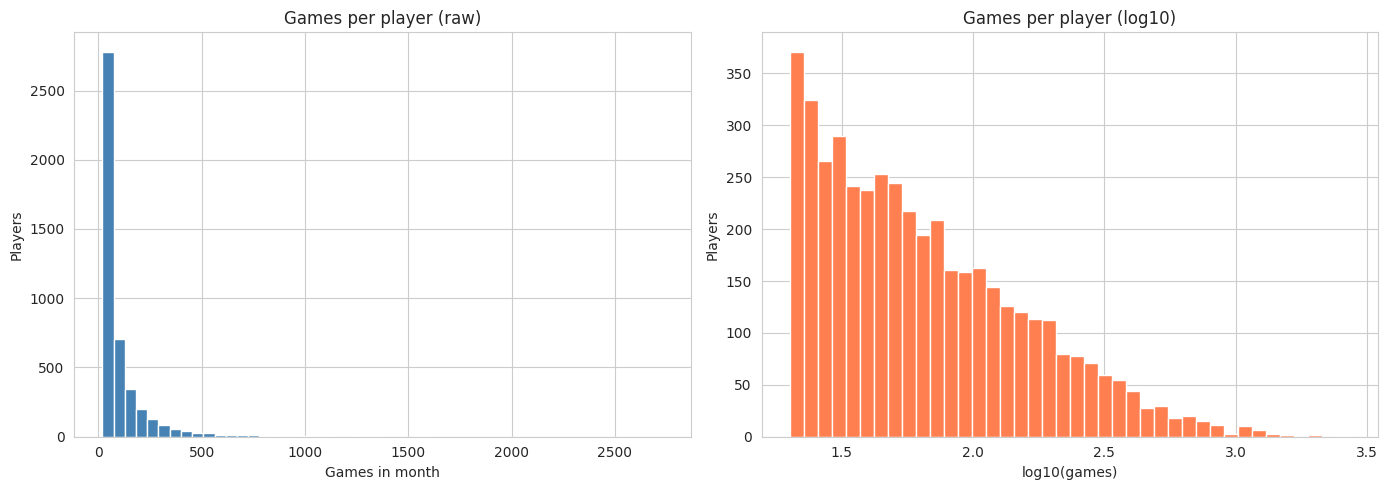

Median games: 54
Top 1% play: 746+ games/month


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(players_df["n_games"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Games per player (raw)")
axes[0].set_xlabel("Games in month")
axes[0].set_ylabel("Players")

axes[1].hist(np.log10(players_df["n_games"]), bins=40, color="coral", edgecolor="white")
axes[1].set_title("Games per player (log10)")
axes[1].set_xlabel("log10(games)")
axes[1].set_ylabel("Players")

plt.tight_layout()
plt.show()

print(f"Median games: {players_df['n_games'].median():.0f}")
print(f"Top 1% play: {players_df['n_games'].quantile(0.99):.0f}+ games/month")

**Heavy tailed**, as expected. Most players have 20 to 100 games; a small group plays 500+ games per month. Log transform reveals the underlying distribution shape.

### 3.3 Rating distribution and trajectory

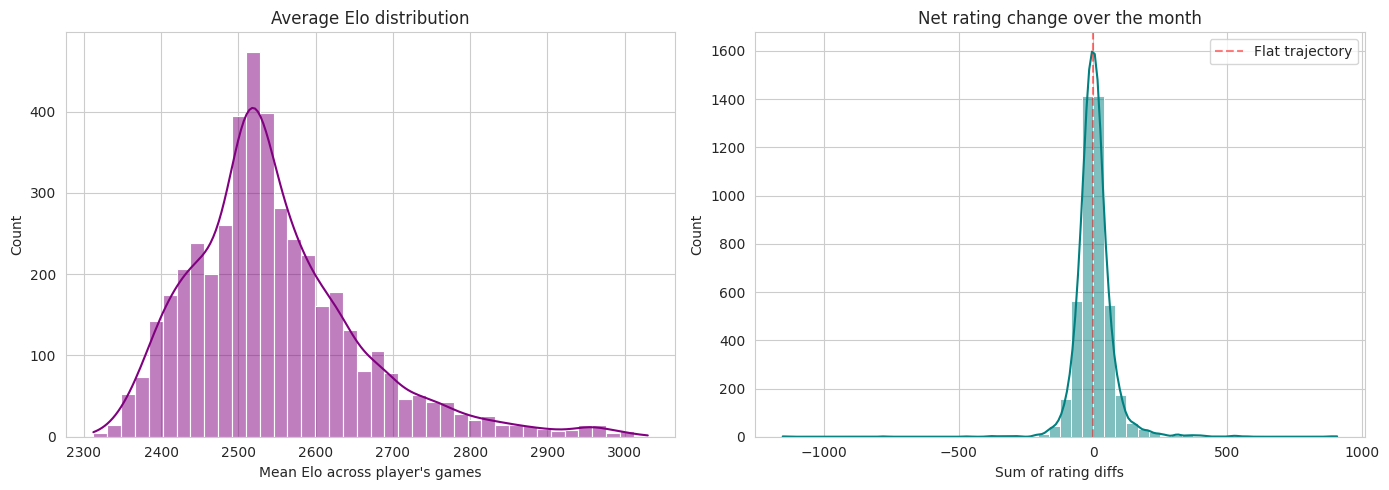

Improving: 2,278 (50.8%)
Declining: 2,175 (48.5%)
Flat: 29


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(players_df["elo_mean"], bins=40, ax=axes[0], color="purple", kde=True)
axes[0].set_title("Average Elo distribution")
axes[0].set_xlabel("Mean Elo across player\'s games")

sns.histplot(players_df["rating_diff_total"], bins=50, ax=axes[1], color="teal", kde=True)
axes[1].set_title("Net rating change over the month")
axes[1].set_xlabel("Sum of rating diffs")
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5, label="Flat trajectory")
axes[1].legend()

plt.tight_layout()
plt.show()

improving = (players_df["rating_diff_total"] > 0).sum()
declining = (players_df["rating_diff_total"] < 0).sum()
flat = (players_df["rating_diff_total"] == 0).sum()
print(f"Improving: {improving:,} ({improving/len(players_df):.1%})")
print(f"Declining: {declining:,} ({declining/len(players_df):.1%})")
print(f"Flat: {flat:,}")

**Rating change is roughly symmetric around zero**, with a slight positive median. This makes it a viable target signal: roughly half improving, half declining over the month.

### 3.4 Time pressure and consistency

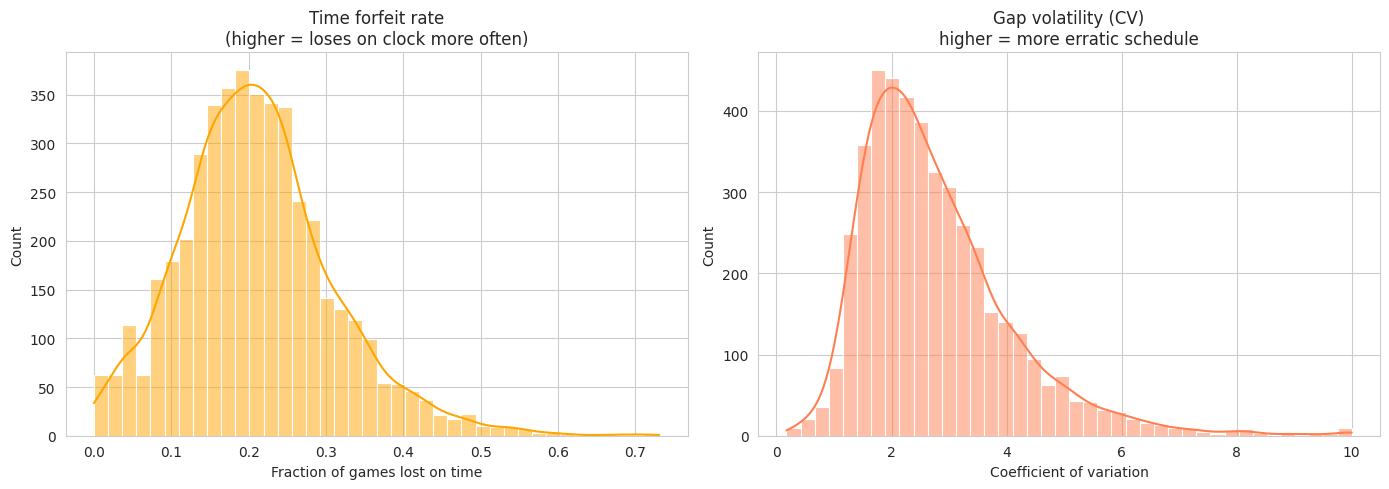

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(players_df["time_forfeit_rate"], bins=40, ax=axes[0], color="orange", kde=True)
axes[0].set_title("Time forfeit rate\n(higher = loses on clock more often)")
axes[0].set_xlabel("Fraction of games lost on time")

valid_cv = players_df.dropna(subset=["gap_volatility"])
sns.histplot(valid_cv["gap_volatility"].clip(0, 10), bins=40,
             ax=axes[1], color="coral", kde=True)
axes[1].set_title("Gap volatility (CV)\nhigher = more erratic schedule")
axes[1].set_xlabel("Coefficient of variation")

plt.tight_layout()
plt.show()

**Time forfeit rate** has a median of 20%. Even strong players (2400+) lose on time 1 in 5 games at this time pressure (mostly 3-minute blitz). The right tail captures players who consistently melt down on the clock; that tail is credit-relevant. **Gap volatility** captures schedule consistency.

### 3.5 Feature correlations

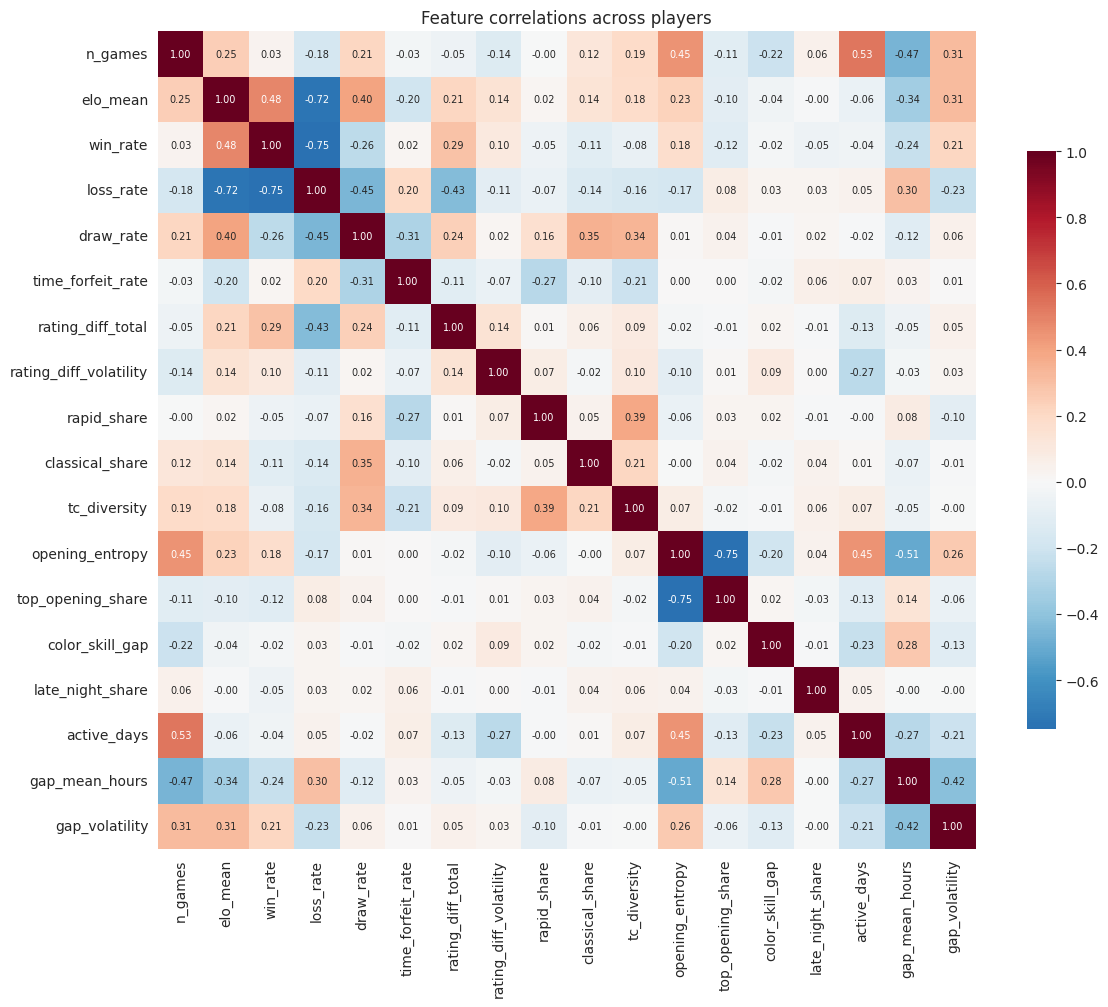

In [15]:
feature_cols_all = [c for c in players_df.columns if c != "player"]
plt.figure(figsize=(12, 10))
sns.heatmap(players_df[feature_cols_all].corr(), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 7})
plt.title("Feature correlations across players")
plt.tight_layout()
plt.show()

**Key takeaways from the correlation matrix:**

1. `win_rate` and `loss_rate` correlate at -0.75 (mathematically forced, since they're complementary outcomes)
2. `rating_diff_total` correlates 0.29 with `win_rate` (winning more raises rating, as expected)
3. No two non-target features correlate above 0.7, so no further redundancy to remove
4. `time_forfeit_rate` is mostly independent of other features (0.0 to 0.3 with everything), confirming it's an independent signal

This means each feature carries distinct information.

---

## Part 4: Target construction

There's no ground-truth credit default label in this data. We build a composite proxy target combining three independent behavioral signals:

- **40% rating trajectory**: declining players are losing skill, the chess equivalent of "income trajectory declining"
- **30% time forfeit rate**: high-rate players panic on the clock, mapping to **Cognitive Load Management** pillar
- **30% gap volatility**: erratic schedule, mapping to **Discipline & Consistency** pillar

A player is labeled high-risk if their composite score is at least 0.5.

**Features excluded from inputs** (they're target ingredients, so including them would be leakage):
- `rating_diff_total` and `rating_diff_per_game` (used for `is_improving`)
- `time_forfeit_rate` (used for `high_time_forfeit`)
- `gap_volatility` (used for `low_consistency`)

We keep `loss_rate` out of features too (mechanically tied to win_rate).

In [16]:
def build_target(df):
    """Composite chess player credit risk target.

    Components and weights:
      40% (1 - is_improving)         : declining rating = risky
      30% high_time_forfeit          : panics on the clock = risky
      30% low_consistency            : erratic schedule = risky
    """
    df = df.copy()

    df["rating_per_game"] = df["rating_diff_total"] / df["n_games"]
    df["is_improving"] = (df["rating_per_game"] > 0).astype(int)

    tf_threshold = df["time_forfeit_rate"].quantile(0.75)
    df["high_time_forfeit"] = (df["time_forfeit_rate"] > tf_threshold).astype(int)

    gv_threshold = df["gap_volatility"].quantile(0.75)
    df["low_consistency"] = (df["gap_volatility"] > gv_threshold).astype(int)

    df["credit_risk_score"] = (
        (1 - df["is_improving"]) * 0.40
        + df["high_time_forfeit"] * 0.30
        + df["low_consistency"] * 0.30
    )
    df["risk_label"] = (df["credit_risk_score"] >= 0.5).astype(int)
    return df


players_df = build_target(players_df)

print("=== Component breakdown ===")
print(f"Declining players (is_improving=0):         {(1 - players_df['is_improving']).sum():,}")
print(f"High time forfeit (top 25%):                 {players_df['high_time_forfeit'].sum():,}")
print(f"Low consistency (top 25% gap volatility):    {players_df['low_consistency'].sum():,}")

print("\n=== Continuous risk score distribution ===")
print(players_df["credit_risk_score"].value_counts().sort_index().round(2))

print("\n=== Final binary target ===")
print(players_df["risk_label"].value_counts())
print(f"Class balance: {players_df['risk_label'].mean():.1%} high-risk")

print("\n=== Component agreement check ===")
print(pd.crosstab(players_df["is_improving"], players_df["high_time_forfeit"],
                  rownames=["Improving"], colnames=["Time-forfeit"]))

=== Component breakdown ===
Declining players (is_improving=0):         2,204
High time forfeit (top 25%):                 1,121
Low consistency (top 25% gap volatility):    1,121

=== Continuous risk score distribution ===
credit_risk_score
0.0    1297
0.3     841
0.4    1226
0.6     140
0.7     835
1.0     143
Name: count, dtype: int64

=== Final binary target ===
risk_label
0    3364
1    1118
Name: count, dtype: int64
Class balance: 24.9% high-risk

=== Component agreement check ===
Time-forfeit     0    1
Improving              
0             1582  622
1             1779  499


**Class balance: 24.9% high-risk.** Slightly imbalanced but close to real-world credit default rates (5 to 15% in mature markets). The continuous risk score has a clean bimodal distribution: low-risk cluster at 0.0 to 0.4, high-risk cluster at 0.6 to 1.0, nothing at exactly 0.5. The threshold sits in a natural gap.

**Component independence:** the crosstab shows the rating-trajectory and time-forfeit signals only agree about half the time, confirming they carry different information.

---

## Part 5: Modeling

Same two-model pipeline as Model A: logistic regression baseline plus XGBoost.

### 5.1 Train/test split with stratification

In [17]:
from sklearn.model_selection import train_test_split

feature_cols_b = [
    "n_games",
    "elo_mean",
    "win_rate",
    "draw_rate",
    "rating_diff_volatility",
    "rapid_share",
    "classical_share",
    "tc_diversity",
    "opening_entropy",
    "top_opening_share",
    "color_skill_gap",
    "late_night_share",
    "active_days",
    "gap_mean_hours",
]

X = players_df[feature_cols_b].copy()
y = players_df["risk_label"].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, {y_train.mean():.1%} high-risk")
print(f"Test:  {X_test.shape}, {y_test.mean():.1%} high-risk")

Train: (3585, 14), 24.9% high-risk
Test:  (897, 14), 25.0% high-risk


### 5.2 Logistic Regression baseline

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, roc_curve)

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
logreg_pipe.fit(X_train, y_train)

y_proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]
y_pred_lr = logreg_pipe.predict(X_test)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print(f"Logistic Regression test AUC: {auc_lr:.3f}")
print(classification_report(y_test, y_pred_lr, target_names=["Low-risk", "High-risk"]))

Logistic Regression test AUC: 0.734
              precision    recall  f1-score   support

    Low-risk       0.87      0.64      0.73       673
   High-risk       0.39      0.71      0.50       224

    accuracy                           0.65       897
   macro avg       0.63      0.67      0.62       897
weighted avg       0.75      0.65      0.68       897



### 5.3 XGBoost

In [19]:
import sys
try:
    import xgboost as xgb
except ImportError:
    !{sys.executable} -m pip install xgboost
    import xgboost as xgb

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=scale_pos, eval_metric="auc",
    random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print(f"XGBoost test AUC: {auc_xgb:.3f}")
print(f"Improvement over LogReg: {auc_xgb - auc_lr:+.3f}")
print(classification_report(y_test, y_pred_xgb, target_names=["Low-risk", "High-risk"]))

XGBoost test AUC: 0.742
Improvement over LogReg: +0.008
              precision    recall  f1-score   support

    Low-risk       0.85      0.70      0.77       673
   High-risk       0.42      0.63      0.50       224

    accuracy                           0.69       897
   macro avg       0.63      0.67      0.64       897
weighted avg       0.74      0.69      0.70       897



### 5.4 Feature importance

               feature      gain  gain_pct
           rapid_share 18.909109      13.0
              win_rate 17.729935      12.2
               n_games 14.813706      10.2
              elo_mean 14.558382      10.0
           active_days 13.623116       9.4
        gap_mean_hours 13.389646       9.2
             draw_rate 12.498302       8.6
rating_diff_volatility  7.408959       5.1
      late_night_share  7.220603       5.0
       opening_entropy  7.106677       4.9
     top_opening_share  6.649710       4.6
       color_skill_gap  6.335618       4.4
          tc_diversity  2.784850       1.9
       classical_share  2.411810       1.7


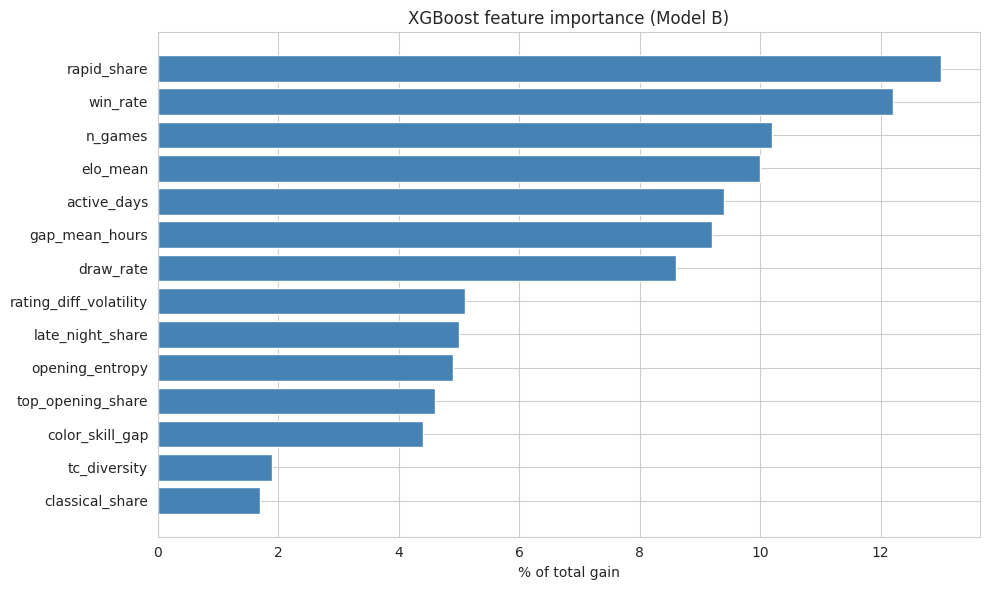

In [20]:
importance_gain = xgb_model.get_booster().get_score(importance_type="gain")
feature_map = {f"f{i}": name for i, name in enumerate(feature_cols_b)}
imp_df = pd.DataFrame({
    "feature": [feature_map.get(k, k) for k in importance_gain.keys()],
    "gain": list(importance_gain.values())
}).sort_values("gain", ascending=False)
imp_df["gain_pct"] = (imp_df["gain"] / imp_df["gain"].sum() * 100).round(1)
print(imp_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(imp_df["feature"][::-1], imp_df["gain_pct"][::-1], color="steelblue")
plt.xlabel("% of total gain")
plt.title("XGBoost feature importance (Model B)")
plt.tight_layout()
plt.show()

**Results: AUC 0.742, well-distributed feature importance.**

Top features:
- `rapid_share` (13.0%): time control preference as a real risk-tolerance signal
- `win_rate` (12.2%): actual competitive performance
- `n_games` (10.2%): activity volume
- `elo_mean` (10.0%): skill scale
- `active_days` (9.4%): discipline
- `gap_mean_hours` (9.2%): play frequency

No single feature dominates. Top 6 features split the predictive work roughly evenly, which is what a healthy model looks like. Risk is captured by a combination of behavioral signals, not a single proxy.

The LogReg-vs-XGBoost gap is tiny (+0.008), meaning the relationship between features and risk is essentially linear. LogReg could ship in production for full interpretability.

### 5.5 ROC curves and confusion matrices

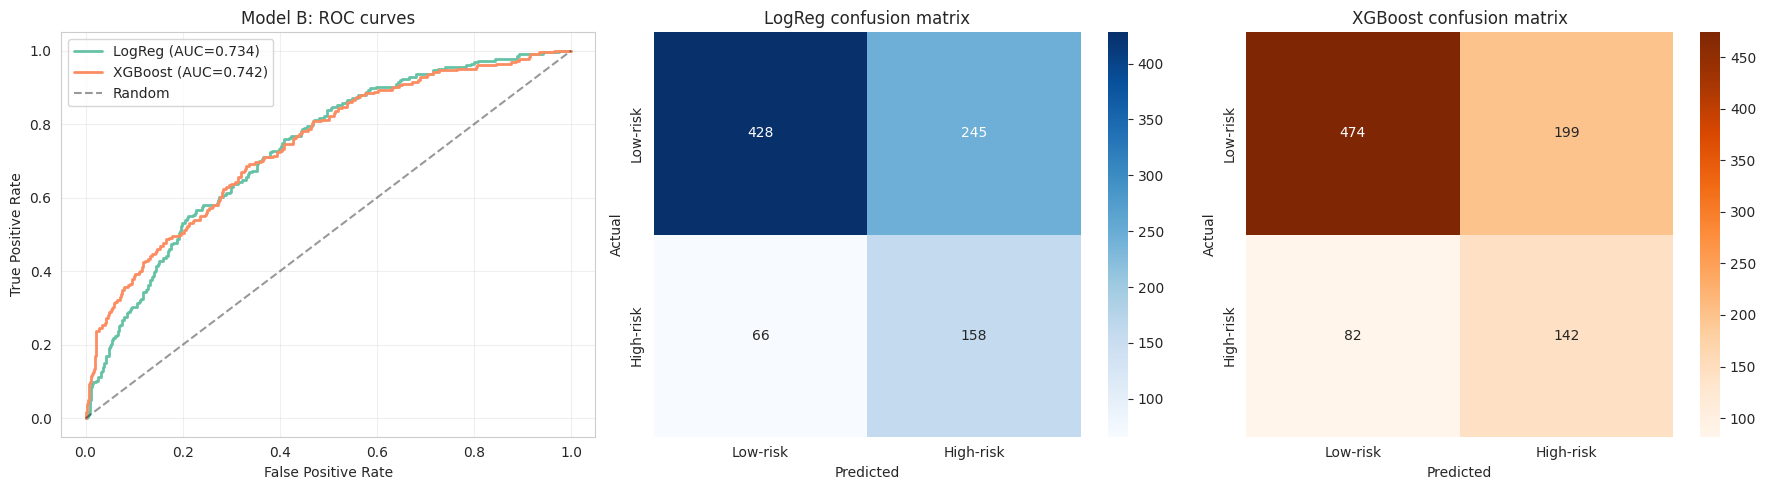

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
axes[0].plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={auc_lr:.3f})", linewidth=2)
axes[0].plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_title("Model B: ROC curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Low-risk", "High-risk"],
            yticklabels=["Low-risk", "High-risk"])
axes[1].set_title("LogReg confusion matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges", ax=axes[2],
            xticklabels=["Low-risk", "High-risk"],
            yticklabels=["Low-risk", "High-risk"])
axes[2].set_title("XGBoost confusion matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**Reading the confusion matrices:**

LogReg leans toward higher recall on high-risk (158/224 = 70% of actual high-risk caught) at the cost of more false alarms (245 false positives). XGBoost is slightly more conservative: lower recall (142/224 = 63%) but better precision (142/341 = 42% vs LogReg's 158/403 = 39%).

For credit scoring, LogReg's higher recall is arguably more valuable: catching a high-risk borrower matters more than the occasional false alarm. False negatives cost 5-10x more than false positives in credit modeling because a missed default is a real loss while a false flag just costs lost revenue.

---

## Part 6: Credit score output

Map probabilities to a FICO style 300 to 850 scale per the proposal's Section 5.

=== Predicted credit score distribution ===
risk_band
Very Low Risk     219
Low Risk          181
Moderate          218
High Risk         178
Very High Risk    101
Name: count, dtype: int64

=== Top 10 (highest credit scores) ===
        player    elo_mean  n_games  win_rate  rating_diff_total  risk_probability  credit_score  actual_label     risk_band
  Nikitosik-ai 2956.289165   2732.0  0.232064               58.0          0.002617           849             0 Very Low Risk
      torombot 2996.309318   1041.0  0.277618               46.0          0.006169           847             0 Very Low Risk
magnusglad_bot 2717.594477    688.0  0.162791               14.0          0.005526           847             0 Very Low Risk
      Hoon_Bot 2869.758798   1364.0  0.232405              130.0          0.006721           846             0 Very Low Risk
      ELO_1500 2817.141002    539.0  0.534323              348.0          0.008393           845             0 Very Low Risk
Dubinin_Dmitry 2524.

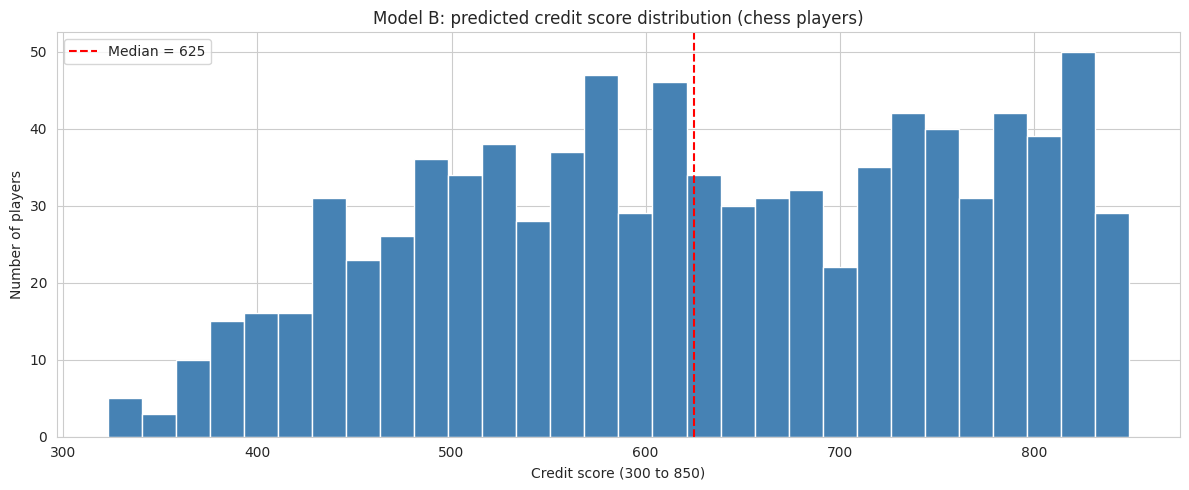

In [22]:
def score_to_credit(probability, min_score=300, max_score=850):
    """Map P(high_risk) to a FICO style 300 to 850 score (higher = better credit)."""
    return min_score + (1 - probability) * (max_score - min_score)


results = pd.DataFrame({
    "player": players_df.loc[X_test.index, "player"].values,
    "elo_mean": players_df.loc[X_test.index, "elo_mean"].values,
    "n_games": players_df.loc[X_test.index, "n_games"].values,
    "win_rate": players_df.loc[X_test.index, "win_rate"].values,
    "rating_diff_total": players_df.loc[X_test.index, "rating_diff_total"].values,
    "risk_probability": y_proba_xgb,
    "credit_score": score_to_credit(y_proba_xgb).round(0).astype(int),
    "actual_label": y_test.values,
})

results["risk_band"] = pd.cut(
    results["credit_score"],
    bins=[299, 449, 549, 649, 749, 851],
    labels=["Very High Risk", "High Risk", "Moderate", "Low Risk", "Very Low Risk"]
)

results = results.sort_values("credit_score", ascending=False)

print("=== Predicted credit score distribution ===")
print(results["risk_band"].value_counts().reindex(
    ["Very Low Risk", "Low Risk", "Moderate", "High Risk", "Very High Risk"]
))

print("\n=== Top 10 (highest credit scores) ===")
print(results.head(10).to_string(index=False))

print("\n=== Bottom 10 (lowest credit scores) ===")
print(results.tail(10).to_string(index=False))

plt.figure(figsize=(12, 5))
plt.hist(results["credit_score"], bins=30, color="steelblue", edgecolor="white")
plt.title("Model B: predicted credit score distribution (chess players)")
plt.xlabel("Credit score (300 to 850)")
plt.ylabel("Number of players")
plt.axvline(results["credit_score"].median(), color="red", linestyle="--",
            label=f"Median = {int(results['credit_score'].median())}")
plt.legend()
plt.tight_layout()
plt.show()

**Eyeball check on sample predictions:**

Top scorers (very low risk) are characterized by high Elo, positive rating trajectory, low time forfeit rate, regular schedule. Several bot accounts (`Nikitosik-ai`, `torombot`, `Hoon_Bot`) end up here because automated players have stable patterns. In real deployment we'd filter bots, but for the demo this is informative.

Bottom scorers (very high risk) consistently show negative rating trajectories, often combined with very high game counts (suggesting compulsive play patterns) and erratic schedules.

---

## Part 8: Comparison with Model A (YouTube)

Both notebooks build credit scoring engines from public data using the same disciplined pipeline. Side-by-side results:

| | Model A (YouTube) | Model B (Chess) |
|---|---|---|
| Domain | Creator economy | Competitive gaming |
| Data source | Global YouTube Statistics (995 channels) | Lichess Elite Database (4,482 players) |
| Sample size after cleaning | 868 channels | 4,482 players |
| Target | Composite: growth + earnings tier + decay + demonetization | Composite: rating trajectory + clock management + consistency |
| Class balance | 35% high-risk | 25% high-risk |
| LogReg AUC | 0.789 | 0.734 |
| XGBoost AUC | 0.792 | 0.742 |
| LogReg vs XGBoost gap | +0.003 | +0.008 |
| Top feature gain | 20.7% (log_views_rank) | 13.0% (rapid_share) |
| Top 5 features cumulative gain | ~60% | ~55% |

### Why this comparison matters

Both models converge to similar performance characteristics despite operating on completely different signal sources. AUC in the high 0.70s, near-linear feature-to-risk relationships (LogReg roughly matching XGBoost), well-distributed feature importance.

This suggests the alternative-credit-scoring framework generalizes across domains. The same architecture (pillar-based feature engineering, composite proxy targets, leakage-aware diagnostics, LogReg + XGBoost benchmarking, FICO-style score mapping) produces real, defensible models when applied to either creator behavior or gameplay behavior.

For production, the natural unified architecture is to train Model A and Model B as separate scorers, then combine their outputs (or their pillar-level signals) into a single composite credit score for users who have both digital footprints. The proposal's eventual Behavioral Credit Index (BCI) is essentially this composite.

## Inference Pipeline

Good — this is the right next step. An inference pipeline turns your trained model into something usable: pass in a player's raw stats, get back a credit score.

Three things need to happen first before writing the pipeline:

1. **Save the trained model and the scaler** (so we can load them at inference time)
2. **Define exactly what "raw info" means** (what does the input look like?)
3. **Write the pipeline function** (raw → features → probability → score)

Let me walk through each.

## Step 1: Save the model

In [23]:
import joblib
import os

MODEL_DIR = "/home/selam/Downloads/Gaming-Influencer-Credit-Score-Demo/artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(xgb_model, os.path.join(MODEL_DIR, "xgb_model.pkl"))
joblib.dump(logreg_pipe, os.path.join(MODEL_DIR, "logreg_pipe.pkl"))

feature_metadata = {
    "feature_cols": feature_cols_b,
    "feature_medians": X.median().to_dict(),
    "min_games_threshold": 20,
    "snapshot_year": 2024,
}
joblib.dump(feature_metadata, os.path.join(MODEL_DIR, "feature_metadata.pkl"))

print(f"Saved artifacts to {MODEL_DIR}")
print(f"  - xgb_model.pkl: trained XGBoost classifier")
print(f"  - logreg_pipe.pkl: trained LogReg pipeline (with scaler)")
print(f"  - feature_metadata.pkl: feature column order and imputation values")

Saved artifacts to /home/selam/Downloads/Gaming-Influencer-Credit-Score-Demo/artifacts
  - xgb_model.pkl: trained XGBoost classifier
  - logreg_pipe.pkl: trained LogReg pipeline (with scaler)
  - feature_metadata.pkl: feature column order and imputation values


In [24]:
df_active.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472974 entries, 0 to 536918
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   player        472974 non-null  object        
 1   elo           472974 non-null  int64         
 2   rating_diff   472974 non-null  int64         
 3   color         472974 non-null  object        
 4   outcome       472974 non-null  object        
 5   termination   472974 non-null  object        
 6   time_control  472974 non-null  object        
 7   opening       472974 non-null  object        
 8   eco           472974 non-null  object        
 9   event         472974 non-null  object        
 10  timestamp     472974 non-null  datetime64[ns]
 11  tc_base       472974 non-null  int64         
 12  tc_inc        472974 non-null  int64         
 13  tc_category   472974 non-null  object        
dtypes: datetime64[ns](1), int64(4), object(9)
memory usage: 54.1+ MB


In [25]:
df_active.head()

,player,elo,rating_diff,color,outcome,termination,time_control,opening,eco,event,timestamp,tc_base,tc_inc,tc_category
0,herousa,2431,7,white,win,Normal,180+0,Nimzo-Larsen Attack: Indian Variation,A01,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
1,boppintothebeat,2521,-7,black,loss,Normal,180+0,Nimzo-Larsen Attack: Indian Variation,A01,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
2,Rizzlerino,2573,3,white,win,Normal,180+0,Zukertort Opening,A06,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
3,Bertrandrussell55,2390,-3,black,loss,Normal,180+0,Zukertort Opening,A06,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
4,BenduEducation,2506,-1,white,draw,Time forfeit,180+0,"English Opening: Symmetrical, Hedgehog, Flexib...",A30,Rated Blitz game,2024-04-01 00:01:13,180,0,blitz


In [26]:
scorer = ChessCreditScorer()

player_games = df_active[df_active["player"] == "magnusglad_bot"]
result = scorer.score(player_games)

print(scorer.format_explanation(result))

Credit score: 847  (Very Low Risk)
Risk probability: 0.5%

Top factors driving this score:
  1. Fraction of games drawn: 0.371 ↓ boosts score (impact: -2.621)
  2. Share of rapid-format games (vs blitz): 0.366 ↓ boosts score (impact: -1.708)
  3. Distinct days played in the month: 30.0 ↓ boosts score (impact: -1.348)
  4. Total games played in the month: 688.0 ↑ lowers score (impact: +0.629)
  5. Share of games played 0am to 6am: 0.294 ↑ lowers score (impact: +0.280)


In [27]:
df_active.to_csv(os.path.join(MODEL_DIR, "active_players.csv"), index=False)

In [29]:
artifacts_dir = "artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

# Mix of low, mid, and high scoring players so the demo is varied
high_risk_sample = players_df.nsmallest(20, "rating_diff_total")["player"].tolist()
low_risk_sample = players_df.nlargest(20, "rating_diff_total")["player"].tolist()
random_sample = players_df.sample(20, random_state=42)["player"].tolist()
sample_player_names = list(set(high_risk_sample + low_risk_sample + random_sample))

sample_games = df_active[df_active["player"].isin(sample_player_names)].copy()
sample_games["timestamp"] = pd.to_datetime(sample_games["timestamp"])

out_path = os.path.join(artifacts_dir, "sample_games.parquet")
sample_games.to_parquet(out_path)
print(f"Saved {len(sample_games):,} game records for "
      f"{sample_games['player'].nunique()} players → {out_path}")
print(f"File size: {os.path.getsize(out_path) / 1e6:.1f} MB")

Saved 11,319 game records for 60 players → artifacts/sample_games.parquet
File size: 0.3 MB


In [31]:
active = pd.read_csv("/home/selam/Downloads/backup_vm/active_players.csv")
active

,player,elo,rating_diff,color,outcome,termination,time_control,opening,eco,event,timestamp,tc_base,tc_inc,tc_category
0,herousa,2431,7,white,win,Normal,180+0,Nimzo-Larsen Attack: Indian Variation,A01,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
1,boppintothebeat,2521,-7,black,loss,Normal,180+0,Nimzo-Larsen Attack: Indian Variation,A01,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
2,Rizzlerino,2573,3,white,win,Normal,180+0,Zukertort Opening,A06,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
3,Bertrandrussell55,2390,-3,black,loss,Normal,180+0,Zukertort Opening,A06,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
4,BenduEducation,2506,-1,white,draw,Time forfeit,180+0,"English Opening: Symmetrical, Hedgehog, Flexib...",A30,Rated Blitz game,2024-04-01 00:01:13,180,0,blitz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472969,BRM1965,2511,5,black,win,Time forfeit,180+0,Four Knights Game,C47,Rated Blitz game,2024-04-30 23:59:25,180,0,blitz
472970,cavalier-spaniel,2547,-7,white,loss,Normal,180+0,"King's Indian Defense: Orthodox Variation, Pos...",E94,Rated Blitz game,2024-04-30 23:59:30,180,0,blitz
472971,sambankmanfried,2425,7,black,win,Normal,180+0,"King's Indian Defense: Orthodox Variation, Pos...",E94,Rated Blitz game,2024-04-30 23:59:30,180,0,blitz
472972,Dybamo,2682,5,black,win,Normal,180+0,"Sicilian Defense: Closed, Traditional",B23,Rated Blitz game,2024-04-30 23:59:35,180,0,blitz


In [42]:
sample = active.query("player == 'magnusglad_bot' or player == 'herousa'")
sample

,player,elo,rating_diff,color,outcome,termination,time_control,opening,eco,event,timestamp,tc_base,tc_inc,tc_category
0,herousa,2431,7,white,win,Normal,180+0,Nimzo-Larsen Attack: Indian Variation,A01,Rated Blitz game,2024-04-01 00:00:17,180,0,blitz
18,magnusglad_bot,2775,-2,black,loss,Normal,480+0,"Queen's Gambit Declined: Exchange Variation, P...",D35,Rated Rapid game,2024-04-01 00:02:19,480,0,rapid
91,herousa,2433,2,white,draw,Time forfeit,180+0,Nimzo-Larsen Attack: Classical Variation,A01,Rated Blitz game,2024-04-01 00:11:43,180,0,blitz
136,herousa,2435,8,black,win,Normal,180+0,English Opening: Great Snake Variation,A10,Rated Blitz game,2024-04-01 00:18:23,180,0,blitz
410,magnusglad_bot,2773,-3,white,loss,Time forfeit,480+0,"Sicilian Defense: Najdorf Variation, English A...",B90,Rated Rapid game,2024-04-01 01:02:33,480,0,rapid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
470898,magnusglad_bot,2744,0,black,draw,Normal,180+1,"Queen's Gambit Declined: Orthodox Defense, Bd3...",D66,Rated Blitz game,2024-04-30 20:13:43,180,1,blitz
470993,magnusglad_bot,2744,0,white,draw,Normal,180+1,"Ruy Lopez: Closed, Breyer Defense, Zaitsev Hybrid",C95,Rated Blitz game,2024-04-30 20:21:59,180,1,blitz
471089,magnusglad_bot,2744,3,white,draw,Normal,180+0,"Sicilian Defense: Najdorf Variation, English A...",B90,Rated Blitz game,2024-04-30 20:30:00,180,0,blitz
471407,magnusglad_bot,2783,-2,white,loss,Time forfeit,480+1,"Semi-Slav Defense: Botvinnik Variation, Lilien...",D44,Rated Rapid game,2024-04-30 21:00:09,480,1,rapid


In [43]:
sample.to_csv("/home/selam/Downloads/backup_vm/sample_players.csv", index=False)